In [792]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [793]:
df = pd.read_csv("../data/raw/matches.csv")
df.head()

,key_id,tournament_id,tournament_name,match_id,match_name,stage_name,group_name,group_stage,knockout_stage,replayed,...,away_team_score_margin,extra_time,penalty_shootout,score_penalties,home_team_score_penalties,away_team_score_penalties,result,home_team_win,away_team_win,draw
0,1,WC-1930,1930 FIFA Men's World Cup,M-1930-01,France vs Mexico,group stage,Group 1,1,0,0,...,-3,0,0,0-0,0,0,home team win,1,0,0
1,2,WC-1930,1930 FIFA Men's World Cup,M-1930-02,United States vs Belgium,group stage,Group 4,1,0,0,...,-3,0,0,0-0,0,0,home team win,1,0,0
2,3,WC-1930,1930 FIFA Men's World Cup,M-1930-03,Yugoslavia vs Brazil,group stage,Group 2,1,0,0,...,-1,0,0,0-0,0,0,home team win,1,0,0
3,4,WC-1930,1930 FIFA Men's World Cup,M-1930-04,Romania vs Peru,group stage,Group 3,1,0,0,...,-2,0,0,0-0,0,0,home team win,1,0,0
4,5,WC-1930,1930 FIFA Men's World Cup,M-1930-05,Argentina vs France,group stage,Group 1,1,0,0,...,-1,0,0,0-0,0,0,home team win,1,0,0


In [794]:
print(f"Raw data shape: {df.shape}\n")
print(f"Columns: \n{df.columns}\n")
print(f"Misisng values: \n{df.isnull().sum()}")

Raw data shape: (1248, 37)

Columns: 
Index(['key_id', 'tournament_id', 'tournament_name', 'match_id', 'match_name',
       'stage_name', 'group_name', 'group_stage', 'knockout_stage', 'replayed',
       'replay', 'match_date', 'match_time', 'stadium_id', 'stadium_name',
       'city_name', 'country_name', 'home_team_id', 'home_team_name',
       'home_team_code', 'away_team_id', 'away_team_name', 'away_team_code',
       'score', 'home_team_score', 'away_team_score', 'home_team_score_margin',
       'away_team_score_margin', 'extra_time', 'penalty_shootout',
       'score_penalties', 'home_team_score_penalties',
       'away_team_score_penalties', 'result', 'home_team_win', 'away_team_win',
       'draw'],
      dtype='object')

Misisng values: 
key_id                       0
tournament_id                0
tournament_name              0
match_id                     0
match_name                   0
stage_name                   0
group_name                   0
group_stage               

In [795]:
# The card system was introduced in 1970; there was no such system prior to that, so we drop the previous tournaments

df["match_date"] = pd.to_datetime(df["match_date"])
df = df[df["match_date"].dt.year >= 1970]

# This work focuses on FIFA Men's World Cup only
df = df[df["tournament_name"].str.contains("Men's")]

print(f"Current data shape: {df.shape}")
df.head()

Current data shape: (764, 37)


,key_id,tournament_id,tournament_name,match_id,match_name,stage_name,group_name,group_stage,knockout_stage,replayed,...,away_team_score_margin,extra_time,penalty_shootout,score_penalties,home_team_score_penalties,away_team_score_penalties,result,home_team_win,away_team_win,draw
200,201,WC-1970,1970 FIFA Men's World Cup,M-1970-01,Mexico vs Soviet Union,group stage,Group 1,1,0,0,...,0,0,0,0-0,0,0,draw,0,0,1
201,202,WC-1970,1970 FIFA Men's World Cup,M-1970-02,Uruguay vs Israel,group stage,Group 2,1,0,0,...,-2,0,0,0-0,0,0,home team win,1,0,0
202,203,WC-1970,1970 FIFA Men's World Cup,M-1970-03,England vs Romania,group stage,Group 3,1,0,0,...,-1,0,0,0-0,0,0,home team win,1,0,0
203,204,WC-1970,1970 FIFA Men's World Cup,M-1970-04,Peru vs Bulgaria,group stage,Group 4,1,0,0,...,-1,0,0,0-0,0,0,home team win,1,0,0
204,205,WC-1970,1970 FIFA Men's World Cup,M-1970-05,Belgium vs El Salvador,group stage,Group 1,1,0,0,...,-3,0,0,0-0,0,0,home team win,1,0,0


In [796]:
# drop unused/irrelevant columns

df = df.drop(columns = ["key_id", "group_name", "match_time", "replay", "replayed", "country_name", "stadium_id", "stadium_name", "city_name",
                        "group_stage", "knockout_stage", "home_team_code", "away_team_code", 
                        "away_team_score_margin", "score_penalties"]).reset_index().drop(columns = "index")
print(f"Current data shape: {df.shape} \n")
print(f"Columns: {df.columns} \n")
df.head()

Current data shape: (764, 22) 

Columns: Index(['tournament_id', 'tournament_name', 'match_id', 'match_name',
       'stage_name', 'match_date', 'home_team_id', 'home_team_name',
       'away_team_id', 'away_team_name', 'score', 'home_team_score',
       'away_team_score', 'home_team_score_margin', 'extra_time',
       'penalty_shootout', 'home_team_score_penalties',
       'away_team_score_penalties', 'result', 'home_team_win', 'away_team_win',
       'draw'],
      dtype='object') 



,tournament_id,tournament_name,match_id,match_name,stage_name,match_date,home_team_id,home_team_name,away_team_id,away_team_name,...,away_team_score,home_team_score_margin,extra_time,penalty_shootout,home_team_score_penalties,away_team_score_penalties,result,home_team_win,away_team_win,draw
0,WC-1970,1970 FIFA Men's World Cup,M-1970-01,Mexico vs Soviet Union,group stage,1970-05-31,T-46,Mexico,T-72,Soviet Union,...,0,0,0,0,0,0,draw,0,0,1
1,WC-1970,1970 FIFA Men's World Cup,M-1970-02,Uruguay vs Israel,group stage,1970-06-02,T-84,Uruguay,T-40,Israel,...,0,2,0,0,0,0,home team win,1,0,0
2,WC-1970,1970 FIFA Men's World Cup,M-1970-03,England vs Romania,group stage,1970-06-02,T-28,England,T-61,Romania,...,0,1,0,0,0,0,home team win,1,0,0
3,WC-1970,1970 FIFA Men's World Cup,M-1970-04,Peru vs Bulgaria,group stage,1970-06-02,T-56,Peru,T-10,Bulgaria,...,2,1,0,0,0,0,home team win,1,0,0
4,WC-1970,1970 FIFA Men's World Cup,M-1970-05,Belgium vs El Salvador,group stage,1970-06-03,T-06,Belgium,T-27,El Salvador,...,0,3,0,0,0,0,home team win,1,0,0


In [797]:
# load the team dataset - confederation lookup 

df_teams = pd.read_csv("../data/raw/teams.csv")
df_teams.head()

,key_id,team_id,team_name,team_code,mens_team,womens_team,federation_name,region_name,confederation_id,confederation_name,confederation_code,mens_team_wikipedia_link,womens_team_wikipedia_link,federation_wikipedia_link
0,1,T-01,Algeria,DZA,1,0,Algerian Football Federation,Africa,CF-2,Confederation of African Football,CAF,https://en.wikipedia.org/wiki/Algeria_national...,not applicable,https://en.wikipedia.org/wiki/Algerian_Footbal...
1,2,T-02,Angola,AGO,1,0,Angolan Football Federation,Africa,CF-2,Confederation of African Football,CAF,https://en.wikipedia.org/wiki/Angola_national_...,not applicable,https://en.wikipedia.org/wiki/Angolan_Football...
2,3,T-03,Argentina,ARG,1,1,Argentine Football Association,South America,CF-4,South American Football Confederation,CONMEBOL,https://en.wikipedia.org/wiki/Argentina_nation...,https://en.wikipedia.org/wiki/Argentina_women'...,https://en.wikipedia.org/wiki/Argentine_Footba...
3,4,T-04,Australia,AUS,1,1,Football Australia,Oceania,CF-1,Asian Football Confederation,AFC,https://en.wikipedia.org/wiki/Australia_men%27...,https://en.wikipedia.org/wiki/Australia_women'...,https://en.wikipedia.org/wiki/Football_Australia
4,5,T-05,Austria,AUT,1,0,Austrian Football Association,Europe,CF-6,Union of European Football Associations,UEFA,https://en.wikipedia.org/wiki/Austria_national...,not applicable,https://en.wikipedia.org/wiki/Austrian_Footbal...


In [798]:
df_teams = df_teams[["team_id", "team_name", "confederation_code"]]
df_teams

,team_id,team_name,confederation_code
0,T-01,Algeria,CAF
1,T-02,Angola,CAF
2,T-03,Argentina,CONMEBOL
3,T-04,Australia,AFC
4,T-05,Austria,UEFA
...,...,...,...
83,T-84,Uruguay,CONMEBOL
84,T-85,Wales,UEFA
85,T-86,West Germany,UEFA
86,T-87,Yugoslavia,UEFA


In [799]:
# match teams in each match to their confederation

df = df.merge(df_teams.rename(columns = {"team_id": "home_team_id"}), 
              on = "home_team_id", 
              how = "left").rename(columns = {"confederation_code": "home_team_confederation"}).drop(columns = "team_name")

df = df.merge(df_teams.rename(columns = {"team_id": "away_team_id"}), 
              on = "away_team_id", 
              how = "left").rename(columns = {"confederation_code": "away_team_confederation"}).drop(columns = "team_name")

In [800]:
print(f"Current columns: {df.columns} \n")

order = ['tournament_id', 'tournament_name', 'match_id', 'match_name',
       'stage_name', 'match_date', 'home_team_id', 'home_team_name',
       'home_team_confederation', 'away_team_id', 'away_team_confederation', 'away_team_name',
       'score', 'home_team_score', 'away_team_score', "home_team_score_margin",  'extra_time', 'penalty_shootout',
       'home_team_score_penalties', 'away_team_score_penalties', 'result',
       'home_team_win', 'away_team_win', 'draw']
df = df.reindex(columns = order)
print("Reset column order:")
df.head()

Current columns: Index(['tournament_id', 'tournament_name', 'match_id', 'match_name',
       'stage_name', 'match_date', 'home_team_id', 'home_team_name',
       'away_team_id', 'away_team_name', 'score', 'home_team_score',
       'away_team_score', 'home_team_score_margin', 'extra_time',
       'penalty_shootout', 'home_team_score_penalties',
       'away_team_score_penalties', 'result', 'home_team_win', 'away_team_win',
       'draw', 'home_team_confederation', 'away_team_confederation'],
      dtype='object') 

Reset column order:


,tournament_id,tournament_name,match_id,match_name,stage_name,match_date,home_team_id,home_team_name,home_team_confederation,away_team_id,...,away_team_score,home_team_score_margin,extra_time,penalty_shootout,home_team_score_penalties,away_team_score_penalties,result,home_team_win,away_team_win,draw
0,WC-1970,1970 FIFA Men's World Cup,M-1970-01,Mexico vs Soviet Union,group stage,1970-05-31,T-46,Mexico,CONCACAF,T-72,...,0,0,0,0,0,0,draw,0,0,1
1,WC-1970,1970 FIFA Men's World Cup,M-1970-02,Uruguay vs Israel,group stage,1970-06-02,T-84,Uruguay,CONMEBOL,T-40,...,0,2,0,0,0,0,home team win,1,0,0
2,WC-1970,1970 FIFA Men's World Cup,M-1970-03,England vs Romania,group stage,1970-06-02,T-28,England,UEFA,T-61,...,0,1,0,0,0,0,home team win,1,0,0
3,WC-1970,1970 FIFA Men's World Cup,M-1970-04,Peru vs Bulgaria,group stage,1970-06-02,T-56,Peru,CONMEBOL,T-10,...,2,1,0,0,0,0,home team win,1,0,0
4,WC-1970,1970 FIFA Men's World Cup,M-1970-05,Belgium vs El Salvador,group stage,1970-06-03,T-06,Belgium,UEFA,T-27,...,0,3,0,0,0,0,home team win,1,0,0


In [801]:
# extract unique teams from dataset

def find_unique_team(data, teams):
    home_team = list(data["home_team_name"].unique())
    print(f"Number of unique home teams: {len(home_team)}")
    print(f"Example teams: {home_team[0:5]} \n")

    away_team = list(data["away_team_name"].unique())
    print(f"Number of unique away teams: {len(away_team)}")
    print(f"Example teams: {away_team[0:5]} \n")

    all_team = list(set(home_team + away_team))
    print(f"Number of unique teams since World Cup 1970: {len(all_team)}")
    print(f"Example teams: {all_team[0:5]} \n")

    unique_team = pd.DataFrame({"team_name": all_team}).merge(teams, on = "team_name", how = "left")
    print(f"Unique teams first few rows: \n{unique_team.head()}")

    return home_team, away_team, all_team, unique_team

In [802]:
home_team, away_team, all_team, unique_team = find_unique_team(df, df_teams)

Number of unique home teams: 80
Example teams: ['Mexico', 'Uruguay', 'England', 'Peru', 'Belgium'] 

Number of unique away teams: 83
Example teams: ['Soviet Union', 'Israel', 'Romania', 'Bulgaria', 'El Salvador'] 

Number of unique teams since World Cup 1970: 83
Example teams: ['New Zealand', 'Scotland', 'China', 'Ivory Coast', 'United States'] 

Unique teams first few rows: 
       team_name team_id confederation_code
0    New Zealand    T-49                OFC
1       Scotland    T-64               UEFA
2          China    T-14                AFC
3    Ivory Coast    T-42                CAF
4  United States    T-83           CONCACAF


In [803]:
df_knockout = df[df["stage_name"] != "group stage"]
home_team_ko, away_team_ko, all_team_ko, unique_team_ko = find_unique_team(df_knockout, df_teams)

Number of unique home teams: 39
Example teams: ['Brazil', 'Italy', 'Soviet Union', 'West Germany', 'Yugoslavia'] 

Number of unique away teams: 47
Example teams: ['Peru', 'Mexico', 'Uruguay', 'England', 'West Germany'] 

Number of unique teams since World Cup 1970: 50
Example teams: ['Italy', 'Belgium', 'Portugal', 'Uruguay', 'Republic of Ireland'] 

Unique teams first few rows: 
             team_name team_id confederation_code
0                Italy    T-41               UEFA
1              Belgium    T-06               UEFA
2             Portugal    T-58               UEFA
3              Uruguay    T-84           CONMEBOL
4  Republic of Ireland    T-60               UEFA


In [804]:
# how many unique teams from each confederation in total and in knock-out stage only

count = unique_team["confederation_code"].value_counts().reset_index()
count = count.merge(unique_team_ko["confederation_code"].value_counts(), on = "confederation_code", how = "left")
count.columns = ["confederation_code", "total", "knock_out"]
count = count.fillna(0)
count["knock_out"] = count["knock_out"].astype(int)
count

,confederation_code,total,knock_out
0,UEFA,39,29
1,CAF,13,6
2,AFC,11,4
3,CONCACAF,10,3
4,CONMEBOL,9,8
5,OFC,1,0


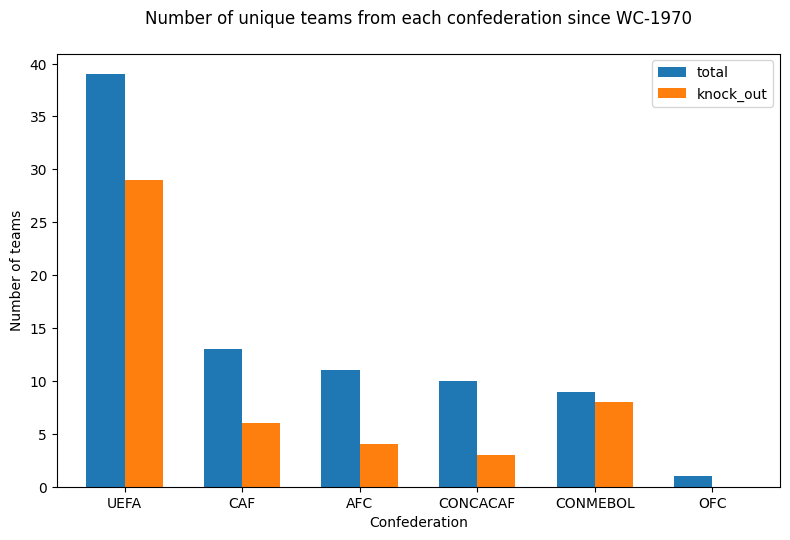

In [805]:
# visualization: bar chart of number of unique teams in total and in knockout stage, by confederatio

count.plot(x = "confederation_code",
           kind = "bar",
           width = 0.65,
           stacked = False,
           figsize = (8, 5.5),
           rot = 0)

plt.ylabel("Number of teams")
plt.xlabel("Confederation")
plt.title("Number of unique teams from each confederation since WC-1970", y = 1.05)
plt.tight_layout()
plt.savefig("../results/unique_team.png", bbox_inches = "tight")

### Takeaways

- **UEFA teams** showed dominance in their presence both in total and in knock-out stage exclusively. Since 1970, nearly 40 **UEFA teams** qualified for the World Cup and nearly 30 made it to the knock-out stage.
- **CAF**, **AFC**, and **CONCACAF** were respectively the second, third, and fourth confederation regarding team presence at World Cup since 1970.
- **CONMEBOL** had fewer teams at World Cup since 1970 than **CAF**, **AFC**, and **CONCACAF**, but was superior in terms of teams qualifiied for the knock-out stage (about 8 **CONMEBOL teams** made it to at least round of 16 since WC-1970)
- **OFC** had only 1 team ever playing at the World Cup, and the team has never qualified for the knock-out stage

In [806]:
# add new columns: win team of each match and their confederation

def return_win_team(row):
    if row["result"] == "home team win":
        return row["home_team_name"]
    elif row["result"] == "away team win":
        return row["away_team_name"]
    else:
        return None
    
def return_win_conf(row):
    if row["result"] == "home team win":
        return row["home_team_confederation"]
    elif row["result"] == "away team win":
        return row["away_team_confederation"]
    else:
        return None

In [807]:
df["win_team_name"] = df.apply(return_win_team, axis = 1)
df["win_team_conf"] = df.apply(return_win_conf, axis = 1)
df.head()

,tournament_id,tournament_name,match_id,match_name,stage_name,match_date,home_team_id,home_team_name,home_team_confederation,away_team_id,...,extra_time,penalty_shootout,home_team_score_penalties,away_team_score_penalties,result,home_team_win,away_team_win,draw,win_team_name,win_team_conf
0,WC-1970,1970 FIFA Men's World Cup,M-1970-01,Mexico vs Soviet Union,group stage,1970-05-31,T-46,Mexico,CONCACAF,T-72,...,0,0,0,0,draw,0,0,1,None,None
1,WC-1970,1970 FIFA Men's World Cup,M-1970-02,Uruguay vs Israel,group stage,1970-06-02,T-84,Uruguay,CONMEBOL,T-40,...,0,0,0,0,home team win,1,0,0,Uruguay,CONMEBOL
2,WC-1970,1970 FIFA Men's World Cup,M-1970-03,England vs Romania,group stage,1970-06-02,T-28,England,UEFA,T-61,...,0,0,0,0,home team win,1,0,0,England,UEFA
3,WC-1970,1970 FIFA Men's World Cup,M-1970-04,Peru vs Bulgaria,group stage,1970-06-02,T-56,Peru,CONMEBOL,T-10,...,0,0,0,0,home team win,1,0,0,Peru,CONMEBOL
4,WC-1970,1970 FIFA Men's World Cup,M-1970-05,Belgium vs El Salvador,group stage,1970-06-03,T-06,Belgium,UEFA,T-27,...,0,0,0,0,home team win,1,0,0,Belgium,UEFA


In [808]:
# numbers of matches won by teams from each confederation

win_by_conf = pd.DataFrame(df.groupby(["tournament_id", "win_team_conf"]).size().unstack().reset_index())
win_by_conf = win_by_conf.fillna(0)
win_by_conf["OFC"] = np.zeros(14)
win_by_conf[['AFC', 'CAF', 'CONCACAF', 'CONMEBOL', 'OFC', 'UEFA']] = win_by_conf[['AFC', 'CAF', 'CONCACAF', 'CONMEBOL', 'OFC', 'UEFA']].astype(int)
win_by_conf.columns = ["tournament_id", "AFC_win", "CAF_win", "CONCACAF_win", "CONMEBOL_win", "UEFA_win", "OFC_win"]
win_by_conf.head()

,tournament_id,AFC_win,CAF_win,CONCACAF_win,CONMEBOL_win,UEFA_win,OFC_win
0,WC-1970,0,0,2,10,15,0
1,WC-1974,0,0,0,4,24,0
2,WC-1978,0,1,0,11,17,0
3,WC-1982,0,2,0,6,28,0
4,WC-1986,0,1,3,11,26,0


In [809]:
# numbers of matches played by teams from each confederation - by home and away

home_by_conf = df.groupby(["tournament_id", "home_team_confederation"]).size().unstack().reset_index().fillna(0)
away_by_conf = df.groupby(["tournament_id", "away_team_confederation"]).size().unstack().reset_index().fillna(0)
print("Number of games played by each confederation (home team):")
print(home_by_conf.head())
print("")
print("Number of games played by each confederation (away team):")
print(away_by_conf.head())

Number of games played by each confederation (home team):
home_team_confederation tournament_id  AFC  CAF  CONCACAF  CONMEBOL  OFC  UEFA
0                             WC-1970  0.0  0.0       3.0      10.0  0.0  19.0
1                             WC-1974  2.0  2.0       1.0       9.0  0.0  24.0
2                             WC-1978  0.0  1.0       0.0      16.0  0.0  21.0
3                             WC-1982  0.0  2.0       2.0       9.0  0.0  39.0
4                             WC-1986  4.0  4.0       3.0      12.0  0.0  29.0

Number of games played by each confederation (away team):
away_team_confederation tournament_id  AFC  CAF  CONCACAF  CONMEBOL  OFC  UEFA
0                             WC-1970  0.0  3.0       4.0       6.0  0.0  19.0
1                             WC-1974  1.0  1.0       2.0      10.0  0.0  24.0
2                             WC-1978  3.0  2.0       3.0       4.0  0.0  26.0
3                             WC-1982  3.0  4.0       4.0       7.0  3.0  31.0
4             

In [810]:
# numbers of matches played by teams from each confederation in total

matches_by_conf = pd.concat((home_by_conf, away_by_conf), ignore_index = True).groupby("tournament_id").sum().reset_index()
matches_by_conf[['AFC', 'CAF', 'CONCACAF', 'CONMEBOL', 'OFC', 'UEFA']] = matches_by_conf[['AFC', 'CAF', 'CONCACAF', 'CONMEBOL', 'OFC', 'UEFA']].astype(int)
matches_by_conf.columns = ["tournament_id", "AFC_played", "CAF_played", "CONCACAF_played", "CONMEBOL_played", "OFC_played", "UEFA_played"]
matches_by_conf.head()

,tournament_id,AFC_played,CAF_played,CONCACAF_played,CONMEBOL_played,OFC_played,UEFA_played
0,WC-1970,0,3,7,16,0,38
1,WC-1974,3,3,3,19,0,48
2,WC-1978,3,3,3,20,0,47
3,WC-1982,3,6,6,16,3,70
4,WC-1986,6,7,8,20,0,63


In [811]:
prop_by_conf = matches_by_conf.merge(win_by_conf, on = "tournament_id", how = "left")
prop_by_conf.head()

,tournament_id,AFC_played,CAF_played,CONCACAF_played,CONMEBOL_played,OFC_played,UEFA_played,AFC_win,CAF_win,CONCACAF_win,CONMEBOL_win,UEFA_win,OFC_win
0,WC-1970,0,3,7,16,0,38,0,0,2,10,15,0
1,WC-1974,3,3,3,19,0,48,0,0,0,4,24,0
2,WC-1978,3,3,3,20,0,47,0,1,0,11,17,0
3,WC-1982,3,6,6,16,3,70,0,2,0,6,28,0
4,WC-1986,6,7,8,20,0,63,0,1,3,11,26,0


In [812]:
# return winning proportion

def return_win_prop(data, confederation):
    data[confederation] = data[f"{confederation}_win"] / data[f"{confederation}_played"]

In [813]:
# apply to prop_by_conf and find winning proportion
# drop unused columns

conf_list = ["AFC", "CAF", "CONCACAF", "CONMEBOL", "OFC", "UEFA"]
for conf in conf_list:
    return_win_prop(prop_by_conf, conf)
prop_by_conf = prop_by_conf[['tournament_id', 'AFC', 'CAF', 'CONCACAF', 'CONMEBOL', 'OFC', 'UEFA']].fillna(0)
prop_by_conf

,tournament_id,AFC,CAF,CONCACAF,CONMEBOL,OFC,UEFA
0,WC-1970,0.000000,0.000000,0.285714,0.625000,0.0,0.394737
1,WC-1974,0.000000,0.000000,0.000000,0.210526,0.0,0.500000
2,WC-1978,0.000000,0.333333,0.000000,0.550000,0.0,0.361702
3,WC-1982,0.000000,0.333333,0.000000,0.375000,0.0,0.400000
4,WC-1986,0.000000,0.142857,0.375000,0.550000,0.0,0.412698
5,WC-1990,0.000000,0.375000,0.285714,0.473684,0.0,0.468750
6,WC-1994,0.285714,0.200000,0.250000,0.529412,0.0,0.467742
7,WC-1998,0.083333,0.187500,0.200000,0.478261,0.0,0.462687
8,WC-2002,0.352941,0.235294,0.416667,0.500000,0.0,0.403226
9,WC-2006,0.125000,0.187500,0.076923,0.588235,0.0,0.560606


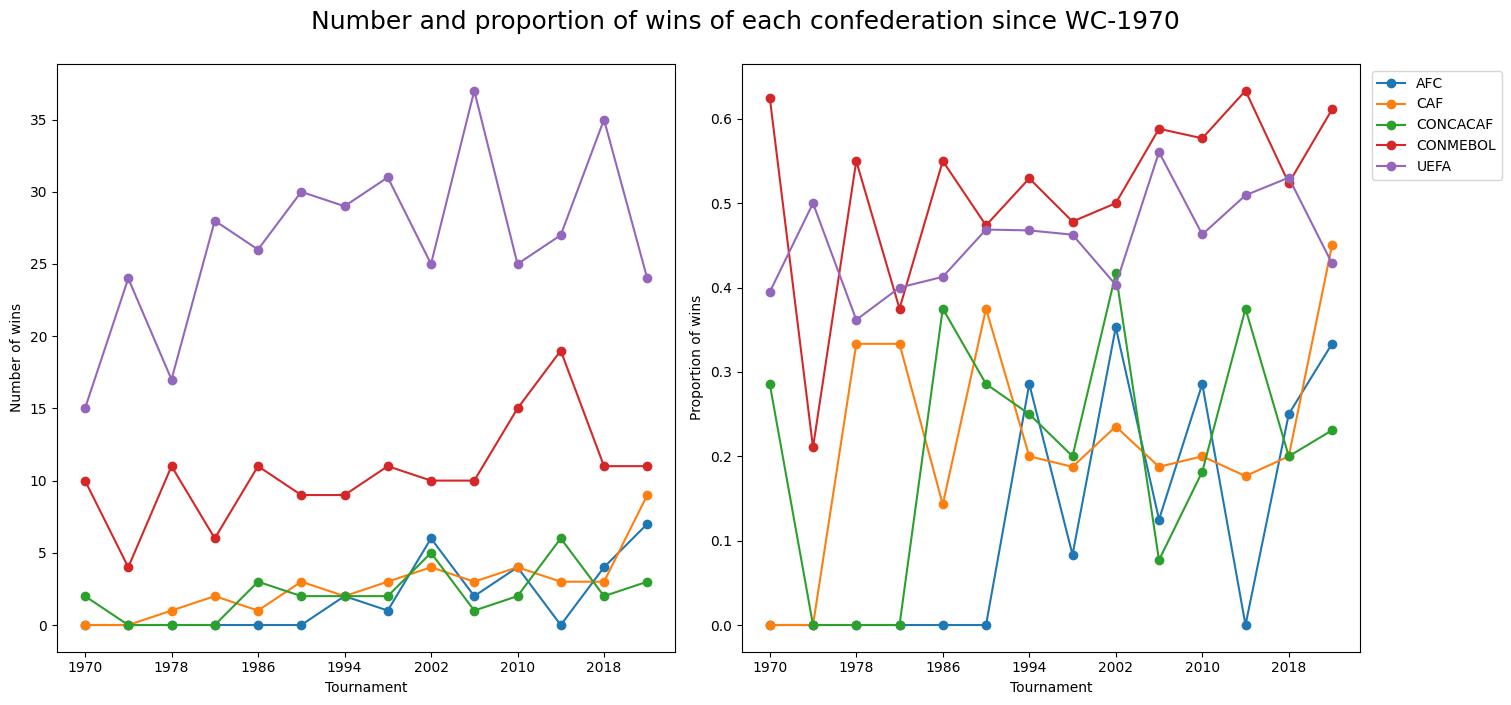

In [833]:
# visualization: line chart of numbers and proportion of wins of each confederation over time 
# proportion is based on matches involving teams from that confederation
# not include OFC because of the flat 0 wins/win proportion

win_by_conf.columns = ['tournament_id', 'AFC', 'CAF', 'CONCACAF', 'CONMEBOL', 'UEFA', 'OFC']
years = win_by_conf['tournament_id'].str.extract(r'(\d+)').astype(int).squeeze().tolist()
years_ticks = []
for i, year in enumerate(years):
    if i % 2 == 0:
        years_ticks.append(year)

fig, ax = plt.subplots(1, 2, figsize = (15, 7))

conf_list = ['AFC', 'CAF', 'CONCACAF', 'CONMEBOL', 'UEFA'] 

for conf in conf_list:
    ax[0].plot(years, win_by_conf[conf], marker = 'o', label = conf)
    ax[1].plot(years, prop_by_conf[conf], marker = 'o', label = conf)

ax[0].set_xticks(years_ticks)
ax[1].set_xticks(years_ticks)
ax[0].set_xlabel("Tournament")
ax[1].set_xlabel("Tournament")
ax[0].set_ylabel("Number of wins")
ax[1].set_ylabel("Proportion of wins")

plt.legend(bbox_to_anchor = (1.24, 1))
plt.suptitle("Number and proportion of wins of each confederation since WC-1970", fontsize = 18, y = 1)
plt.tight_layout()
plt.savefig("../results/win_prop_count_conf.png", bbox_inches = "tight")

### Takeaways

- **UEFA** and **CONMEBOL** were superior to the other confederations in terms of numbers of matches won, especially **UEFA** teams with a great dominance in the number of matches won at World Cup since 1970.
- The dominance of **UEFA** teams' matches won is consistent with their dominant number of teams present and teams qualified for knockouts, which is understandable (as they played more match, there number of wins probably increases)
- **AFC**, **CAF**, and **CONCACAF** all had pretty low number of matches won compared to the other to confederations
- Fluctuations in proportion of wins over time
- CONMEBOL teams consistently had the highest winning proportions over time since 1970, despite playing and winning fewer matches than UEFA teams. They had a drop at 0.2 in 1974, but an upward trend afterwards. UEFA had the 
- Most confederations saw an overall upward trend after fluctuations

This pattern in **UEFA** and **CONMEBOL** dominance in team performance, broadly, is consistent with referee appearance from these two confederations, especially in high-stakes matches (found in `referee_app_eda.ipynb`). Does this reflect a pure coincidence, a part of FIFA's policy, or an underlying structural bias?

This establishes the basic research question of this data visualization project!